/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


=== FSS (var) from *_with_err.npz ===
pc   = 0.856350 ± 0.034239553773870626
nu   = 1.369710 ± 0.17478929025402504
zeta = -3.560155 ± 0.9701742644493875
S    = 0.967414


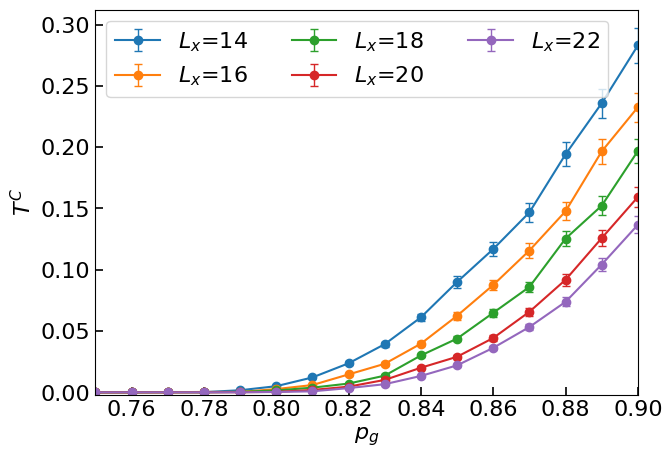

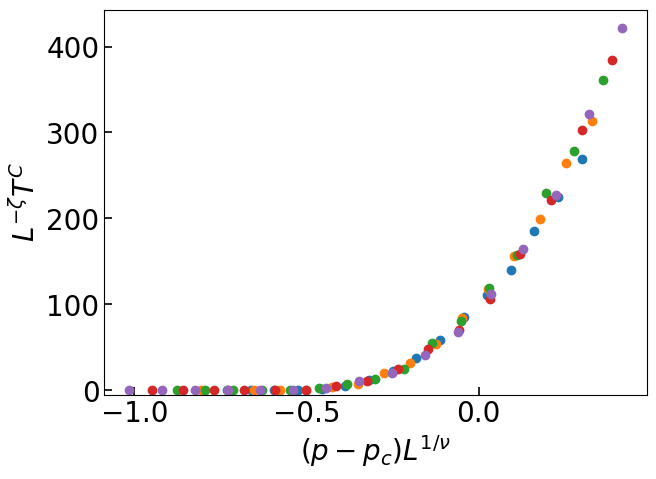

Saved: fig/var_raw.png, fig/var_collapse.png


In [10]:
import numpy as np, glob, re
import matplotlib.pyplot as plt
from pathlib import Path
import fssa
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'  # テキストをフォントのまま保持

# ======================
# ユーザー設定（必要に応じて調整）
# ======================
use_by_value = True          # True にすると p の値で範囲選択
pmin, pmax   = 0.75, 0.9     # use_by_value=True のときだけ有効
use_sqrtL    = False          # L を sqrt(Lx) にするなら True（セル数~面積が L^2 の時など）

rel_err_floor = 0.05          # 誤差の相対フロア
abs_floor_scale = 5e-2     # 絶対フロアのスケール（中央値×この値）

# ======================
# 1) 読み込み（Lx を抽出）
# ======================
files = glob.glob("results_px_*_Lx_*_Nd_*_NT_*_with_err.npz")
if not files:
    raise FileNotFoundError("マッチする npz が見つかりません。パターンやカレントディレクトリを確認してください。")

by_L = {}  # L : (pg, var, var_err)
for fn in files:
    m = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)", fn)
    if not m:
        continue
    Lx = int(m.group(1))
    dat = np.load(fn)
    if not {"pg","R2x_loop_ave","R2x_loop_err"}.issubset(dat.files):
        continue
    pg      = np.asarray(dat["pg"], float)
    var     = np.asarray(dat["R2x_loop_ave"], float)
    var_err = np.asarray(dat["R2x_loop_err"], float)
    by_L[Lx] = (pg, var, var_err)

if len(by_L) < 2:
    raise RuntimeError("異なる L（少なくとも2つ）が必要です。")

#Ls = sorted(by_L.keys())
#Ls=[6,8,10,12,14,16,18,20,22]
Ls=[14,16,18,20,22]
L_arr = np.array(Ls, float)
if use_sqrtL:
    L_arr = np.sqrt(L_arr)

# ======================
# 2) 共通 pg グリッドを作って補間（端は NaN）
# ======================
rho_all = np.unique(np.concatenate([by_L[L][0].astype(float) for L in Ls]))
A_rows, dA_rows = [], []
for L in Ls:
    pg, A, dA = by_L[L]
    pg = np.asarray(pg, float); A = np.asarray(A, float); dA = np.asarray(dA, float)
    if np.array_equal(pg, rho_all):
        Ai, dAi = A.copy(), dA.copy()
    else:
        Ai  = np.interp(rho_all, pg, A,  left=np.nan, right=np.nan)
        dAi = np.interp(rho_all, pg, dA, left=np.nan, right=np.nan)
        xmin, xmax = float(pg.min()), float(pg.max())
        out = (rho_all < xmin) | (rho_all > xmax)
        Ai[out]  = np.nan
        dAi[out] = np.nan
    A_rows.append(Ai); dA_rows.append(dAi)

A_mat  = np.vstack(A_rows)      # 形 (nL, nP)
dA_mat = np.vstack(dA_rows)

# L 全てで有効 & dA>0 の列だけを残す
common = np.all(np.isfinite(A_mat) & np.isfinite(dA_mat) & (dA_mat >= 0), axis=0)
rho = rho_all[common]
A   = A_mat[:, common]
dA  = dA_mat[:, common]

# 誤差の下限（相対 + 絶対）で安定化
abs_floor = (np.nanmedian(np.abs(A)) * abs_floor_scale) if np.isfinite(A).any() else 1e-4
dA = np.maximum(dA, rel_err_floor*np.abs(A) + abs_floor)

# ★追加: フロア適用“後”の健全性チェック（列を再度間引き）
ok = np.all(np.isfinite(A) & np.isfinite(dA) & (dA > 0), axis=0)
rho, A, dA = rho[ok], A[:, ok], dA[:, ok]

if rho.size < 3:
    raise RuntimeError("共通の p 点が少なすぎます。入力データの重なりを確認してください。")

# （任意）p 範囲でさらに絞る
if use_by_value:
    m = (rho >= pmin) & (rho <= pmax)
    if not np.any(m):
        raise ValueError("指定した p 範囲に共通点がありません。pmin/pmax を見直してください。")
    rho, A, dA = rho[m], A[:, m], dA[:, m]

# ======================
# 3) 初期値推定（pc0, nu0, zeta0）
# ======================
nu0 = 1.5
zeta0 = 0.5

argmax_idx = np.nanargmax(A, axis=1)              # 各 L のピーク位置インデックス
pg_max = rho[argmax_idx]
pc0 = float(np.polyval(np.polyfit(1.0/L_arr, pg_max, 1), 0.0))

peak_vals = A[np.arange(len(L_arr)), argmax_idx]
slope = float(np.polyfit(np.log(L_arr), np.log(np.clip(peak_vals, 1e-300, None)), 1)[0])
zeta0 = slope * nu0

# x の探索幅（ピークが入る最小幅 + マージン）
x_need = np.abs((L_arr**(1.0/nu0)) * (pg_max - pc0))
xmax = float(np.nanmax(x_need) + 3.0)
x_bounds = (-xmax, xmax)

# ======================
# 4) autoscale 実行
# ======================
#ret = fssa.autoscale(L_arr, rho, A, dA,
#                     rho_c0=pc0, nu0=nu0, zeta0=zeta0,
#                     x_bounds=x_bounds)

ret = fssa.autoscale(L_arr, rho, A, dA,
                    rho_c0=pc0, nu0=nu0, zeta0=zeta0,   # ← 必須（初期値）
                    x_bounds=x_bounds,fix={"zeta": zeta0})

pc, nu, zeta = float(ret.rho), float(ret.nu), float(ret.zeta)
dpc, dnu, dzeta = float(ret.drho), float(ret.dnu), float(ret.dzeta)

# 縮約データと評価関数 S
xs, ys, dys = fssa.scaledata(L_arr, rho, A, dA, pc, nu, zeta)

# ★追加: 縮約後の誤差に安全フロアを導入（NaN/ゼロ回避）
eps = (np.nanmedian(np.abs(ys)) * 1e-6) if np.isfinite(ys).any() else 1e-8
dys = np.where(np.isfinite(dys) & (dys > 0), dys, eps)

S = fssa.quality(xs, ys, dys)

print("=== FSS (var) from *_with_err.npz ===")
print(f"pc   = {pc:.6f} ± {dpc if np.isfinite(dpc) else np.nan}")
print(f"nu   = {nu:.6f} ± {dnu if np.isfinite(dnu) else np.nan}")
print(f"zeta = {zeta:.6f} ± {dzeta if np.isfinite(dzeta) else np.nan}")
print(f"S    = {S:.6f}")
if hasattr(ret, "S"):
    print(f"S (autoscale) = {ret.S}")

# ======================
# 5) 可視化
# ======================

# Raw
fig, ax = plt.subplots(figsize=(7,5))
for i, Lval in enumerate(L_arr):
    ax.errorbar(rho, A[i], dA[i], fmt='o-', capsize=3, elinewidth=1, capthick=1, label=f"$L_x$={int(Lval)}")
ax.set_xlabel("$p_g$",fontsize=16); ax.set_ylabel("$T^C$",fontsize=16)
#ax.set_title("Raw (X-loop)")
ax.set_xlim(0.75,0.9)
ax.set_ylim(-0.002)
ax.legend(ncol=3, fontsize=16); ax.grid(False)
ax.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=16)
plt.show()
#fig.savefig("Xloop_raw.png", dpi=300, bbox_inches="tight"); plt.close(fig)
fig.savefig("fig_xloop_initial_X/fig_xloop_px_0_ave.svg", format="svg", bbox_inches="tight", transparent=True)

# Collapse
fig, ax = plt.subplots(figsize=(7,5))
for i, Lval in enumerate(L_arr):
    #ax.errorbar(xs[i], ys[i], dys[i], fmt='o', label=f"L={Lval:.2f}")
    ax.plot(xs[i], ys[i], 'o', label=f"L={int(Lval)}")
ax.set_xlabel(r"$(p - p_c)L^{1/\nu}$",fontsize=20)
ax.set_ylabel(r"$L^{-\zeta}T^C$",fontsize=20)
#ax.set_title(f"Collapsed var (S={S:.3f})")
ax.set_ylim(-5)
#ax.legend(ncol=2, fontsize=20); ax.grid(False)
ax.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=20)
plt.show()
#fig.savefig("Xloop_collapse.png", dpi=300, bbox_inches="tight"); plt.close(fig)
fig.savefig("fig_xloop_initial_X/fig_xloop_px_0_ave_collapse.svg", format="svg", bbox_inches="tight", transparent=True)

print("Saved: fig/var_raw.png, fig/var_collapse.png")


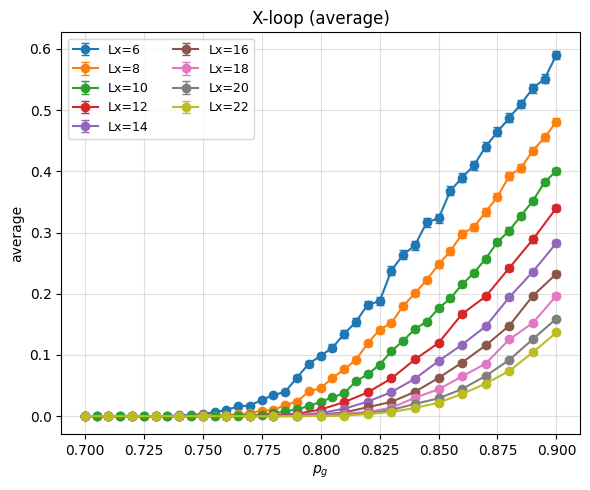

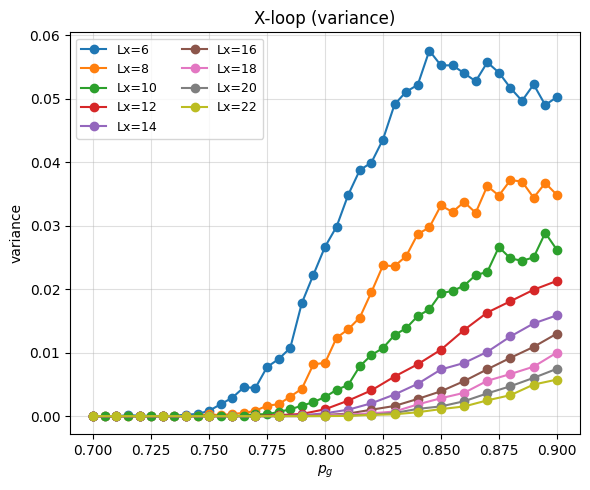

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# ファイルを取得
files = glob.glob("results_px_0.0_Lx_*_Nd_*_NT_*_with_err.npz")

# (Lx, Nd, NT, filename) のタプルを作ってソート
file_info = []
for fname in files:
    match = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)_with_err.npz", fname)
    if match:
        Lx, Nd, NT = map(int, match.groups())
        file_info.append((Lx, Nd, NT, fname))
# Lx の昇順でソート
file_info.sort(key=lambda x: x[0])

# --- average 用の figure ---
fig_avg, ax_avg = plt.subplots(figsize=(6,5))

# --- variance 用の figure ---
fig_var, ax_var = plt.subplots(figsize=(6,5))

for Lx, Nd, NT, fname in file_info:
    data = np.load(fname)
    pg = data["pg"]
    R2x_loop_ave = data["R2x_loop_ave"]
    R2x_loop_err = data["R2x_loop_err"]
    R2x_loop_var = data["R2x_loop_var"]
    order = np.argsort(pg)
    pg = pg[order]
    R2x_loop_ave = R2x_loop_ave[order]
    R2x_loop_err = R2x_loop_err[order]
    R2x_loop_var = R2x_loop_var[order]
    # 平均のプロット
    ax_avg.errorbar(pg, R2x_loop_ave, R2x_loop_err, fmt="-o", capsize=3, elinewidth=1, capthick=1, label=f"Lx={Lx}")
    # 分散のプロット
    ax_var.plot(pg, R2x_loop_var, marker="o", label=f"Lx={Lx}")

# --- average figure の整形 ---
ax_avg.set_xlabel("$p_g$")
ax_avg.set_ylabel("average")
ax_avg.set_title("X-loop (average)")
ax_avg.legend(ncol=2, fontsize=9)
ax_avg.grid(True, alpha=0.4)
fig_avg.tight_layout()
fig_avg.savefig("Xloop_average.png", dpi=300, bbox_inches="tight")

# --- variance figure の整形 ---
ax_var.set_xlabel("$p_g$")
ax_var.set_ylabel("variance")
ax_var.set_title("X-loop (variance)")
ax_var.legend(ncol=2, fontsize=9)
ax_var.grid(True, alpha=0.4)
fig_var.tight_layout()
fig_var.savefig("Xloop_variance.png", dpi=300, bbox_inches="tight")

plt.show()
